In [14]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import numpy as np
from pathlib import Path
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import binned_statistic_2d
import os
os.chdir(Path(os.getcwd()).parent.parent)  # Change to project root
# import metaworld
# import gymnasium as gym
# os.environ['MUJOCO_GL'] = 'egl'

In [15]:
all_envs = ['button', 'coffee', 'door', 'drawer', 'faucet']
configs = {env: {'pixel': [], 'dynamics': [], 'random': []} for env in all_envs}
for i in range(0, 1):
    for policy, objective in zip(['eig', 'maxdyn', 'random'], ['pixel', 'dynamics', 'random']):
        for env in all_envs:
            # if env == 'coffee' and objective == 'pixel':
            #     config = "runs/{env}/{env}_{objective}_{i}/config.yaml".format(env=env, objective=objective, i=5)
            # else:
            config = "runs/{env}/{env}_{objective}_{i}/config.yaml".format(env=env, objective=objective, i=i)
            configs[env][objective].append(config)

In [23]:
PROJECT_ROOT = Path("/home/ayush/Desktop/tutorials/rl_latent/E2C/")
eig_path = 'runs/door/old_door_eig_final_0'
maxdyn_path = 'runs/door/old_door_maxdyn_final_0'
rand_path = 'runs/door/old_door_random_final_0'

env = all_envs[-1]  # 'coffee'
idx = 6 # which run index to use
for idx in range(0, 7):
    paths = [cfg_path[0].split('/config.yaml')[0] for cfg_path in configs[env].values()]
    # paths = [eig_path, maxdyn_path, rand_path]

    pos_titles = []
    states = [torch.load(PROJECT_ROOT / path / f'eval_states_{idx}.pt') for path in paths]
    # states = [torch.load(PROJECT_ROOT / path / f'eval_saved_state.pt') for path in paths]

    # states: list of 3 tensors/arrays; cols: [x, y, z, gripper, x_obj, y_obj, z_obj, reward, xdot, ydot, zdot, gripper_vel, contact]
    states_np = [s.cpu().numpy() if hasattr(s, "cpu") else np.asarray(s) for s in states]
    for i, title in enumerate(range(3)):
        pos_titles.append(f"# Contacts: {np.count_nonzero(states_np[i][:, -1])}")

    bins = 10
    min_count = 1  # for arrows if you add them later

    # Compute global axis limits so columns align visually
    x_min = -0.5 # min(arr[:, 0].min() for arr in states_np)
    x_max = 0.5 # max(arr[:, 0].max() for arr in states_np)
    y_min = 0.3 # min(arr[:, 1].min() for arr in states_np)
    y_max = 0.85 # max(arr[:, 1].max() for arr in states_np)

    def hist2d_with_velocity(arr, bins):
        x, y = arr[:, 0], arr[:, 1]
        vx, vy, vz = arr[:, 8], arr[:, 9], arr[:, 10]
        # TODO: check shape of velocity, ensure dividing by right amount, max velocity should not be able to be more than 0.5
        vel = np.linalg.norm((vx, vy, vz), axis=0) / 4 / 3 # divide by self.meta_ts to get m/s
        occ_pos, xedges, yedges = np.histogram2d(x, y, bins=bins, range=[[x_min, x_max], [y_min, y_max]])
        # occ_vel, _, _ = np.histogram2d(x, y, bins=bins, weights=vel, range=[[x_min, x_max], [y_min, y_max]])
        occ_vel, _, _, _ = binned_statistic_2d(x, y, vel, bins=bins, range=[[x_min, x_max], [y_min, y_max]])
        
        xc = 0.5 * (xedges[:-1] + xedges[1:])
        yc = 0.5 * (yedges[:-1] + yedges[1:])
        return occ_pos, occ_vel, xc, yc, xedges, yedges

    all_occ_pos = []
    all_occ_vel = []

    for arr in states_np:
        occ_pos, occ_vel, _, _, xedges, yedges = hist2d_with_velocity(arr, bins)
        # Mask zeros with NaN before finding min/max
        occ_pos_masked = np.where(occ_pos == 0, np.nan, occ_pos)
        all_occ_pos.append(occ_pos_masked)
        all_occ_vel.append(occ_vel)

    # Global min/max for position row (ignoring NaNs)
    pos_min = np.nanmin([np.nanmin(x) for x in all_occ_pos])
    pos_max = np.nanmax([np.nanmax(x) for x in all_occ_pos])
    vel_min = np.nanmin([np.nanmin(x) for x in all_occ_vel])
    vel_max = np.nanmax([np.nanmax(x) for x in all_occ_vel])

    # fig = make_subplots(rows=2, cols=3, horizontal_spacing=0.1, vertical_spacing=0.1,
    fig = make_subplots(rows=1, cols=3, horizontal_spacing=0.1, vertical_spacing=0.1,
                        subplot_titles=pos_titles)
    fig_width = 1150
    # fig.update_layout(height=850, width=fig_width, template="plotly_white")
    fig.update_layout(height=450, width=fig_width, template="plotly_white")

    # coffee_x, coffee_y = -0.03, 0.52 # states_np[0][20, 0], states_np[0][20, 1] # COFFEE
    coffee_x, coffee_y = states_np[0][58, 0], states_np[0][58, 1] # DOOR
    # button_x, button_y = states_np[0][25, 0], states_np[0][25, 1]
    cam_x, cam_y = -0.7, 0.0
    look_until_x1, look_until_y1 = -0.5, 0.7
    look_until_x2, look_until_y2 = 0.5, 0.0

    for col, arr in enumerate(states_np, start=1):
        occ_pos, occ_vel, xc, yc, xedges, yedges = hist2d_with_velocity(arr, bins)
        occ_pos = np.where(occ_pos == 0, np.nan, occ_pos)

        # Heatmaps: use centers for x/y
        fig.add_trace(
            go.Heatmap(x=xc, y=yc, z=occ_pos.T, colorscale="RdBu_r",
                    zmin=pos_min, zmax=pos_max,
                    colorbar=dict(title="Timesteps", len=0.4 * 2, y=0.5), showscale=(col == 3),
                    #    xgap=5, ygap=5
                    ),
            row=1, col=col,
        )
        # fig.add_trace(
        #     go.Heatmap(x=xc, y=yc, z=occ_vel.T, colorscale="Magma",
        #                zmin=vel_min, zmax=vel_max,
        #                colorbar=dict(title="Velocity (m/s)", len=0.4, y=0.23), showscale=(col == 3)),
        #     row=2, col=col
        # )
        # Top-row markers: start (red circle), end (green circle), object (contrast star)
        start_x, start_y = arr[0, 0], arr[0, 1]
        end_x, end_y = arr[-1, 0], arr[-1, 1]

        fig.add_trace(
            go.Scatter(x=[start_x], y=[start_y], mode="markers",
                    marker=dict(size=10, color="red", symbol="circle"),
                    name=f"start pos", showlegend=(col == 1)),
            row=1, col=col
        )
        fig.add_trace(
            go.Scatter(x=[end_x], y=[end_y], mode="markers",
                    marker=dict(size=10, color="green", symbol="circle"),
                    name=f"end pos", showlegend=(col == 1)),
            row=1, col=col
        )
        # fig.add_trace(
        #     go.Scatter(x=[coffee_x], y=[coffee_y], mode="markers",
        #                marker=dict(size=12, color="#FFD700", symbol="star"),
        #                name=f"object", showlegend=(col == 1)),
        #     row=1, col=col
        # )


    # Axis labels and unified ranges
    for c in range(1, 4):
        fig.update_xaxes(title_text="x", range=[x_min, x_max], row=1, col=c,
                        tickvals=xedges, showgrid=True, gridcolor='rgba(0, 0, 0, 1)',)
        fig.update_yaxes(title_text="y", range=[y_min, y_max], row=1, col=c,
                        tickvals=yedges, showgrid=True, gridcolor='rgba(0, 0, 0, 1)',)
        # fig.update_xaxes(title_text="x", range=[x_min, x_max], row=2, col=c)
        # fig.update_yaxes(title_text="y", range=[y_min, y_max], row=2, col=c)

    # Draw borders around each subplot (mirror axis lines)
    for r in range(1, 2):
        for c in range(1, 4):
            fig.update_xaxes(showline=True, linewidth=1, linecolor="black", mirror=True, zeroline=False, row=r, col=c)
            fig.update_yaxes(showline=True, linewidth=1, linecolor="black", mirror=True, zeroline=False, row=r, col=c)

    # --- Overall figure title (centered, inside figure) ---
    fig.update_layout(
        title=dict(
            text=f"End Effector Position for {env.capitalize()}, Render Seed {idx}",
            x=0.48, xanchor="center",
            y=0.92, yanchor="bottom",        # keep inside the canvas
            font=dict(size=32, family="Arial")
        ),
        # leave room for top title and left row labels
        margin=dict(l=140, r=100, t=100, b=90)
    )

    # --- Shared row titles (rotated 90°, placed in left margin) ---
    row_titles = ["Time Spent<br>at Each Position"] #, "Control Magnitude<br>at Each Position"]
    # approximate row centers in paper coords for 2 rows
    row_ys = [0.92] #, 0.08]
    for y, text in zip(row_ys, row_titles):
        fig.add_annotation(
            x=-0.15, y=y, xref="paper", yref="paper",  # shift left; margin.l ensures room
            text=text, showarrow=False,
            textangle=-90,
            font=dict(size=24),
            align="center"
        )

    # --- Shared column titles (top of each column) ---
    col_titles = ["Pixel Objective", "Dynamic Objective", "Random"]
    ncols = 3
    row_xs = [0.03, 0.5, 0.93]
    for i, text in enumerate(col_titles, start=1):
        # x = (i - 0.5 - (120+100)/fig_width) / (ncols - (120+100)/fig_width)          # column center in paper coords
        fig.add_annotation(
            x=row_xs[i-1], y=1.22, xref="paper", yref="paper",
            text=text, showarrow=False,
            font=dict(size=24),
            align="center"
        )

    # --- Keep legend clear and colorbars separated ---
    fig.update_layout(
        legend=dict(
            orientation="h",
            yanchor="top", y=-0.15,         # below plots
            xanchor="center", x=0.5
        )
    )
    # Optional: nudge colorbars to the right if needed
    for tr in fig.data:
        if isinstance(tr, go.Heatmap) and tr.colorbar:
            tr.update(colorbar=dict(x=1.02))
    fig.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/ayush/Desktop/tutorials/rl_latent/E2C/runs/faucet/faucet_pixel_0/eval_states_0.pt'

In [ ]:
PROJECT_ROOT = Path("/home/ayush/Desktop/tutorials/rl_latent/E2C/")
eig_path = 'runs/coffee/coffee_eig_0'
maxdyn_path = 'runs/coffee/coffee_maxdyn_0'
rand_path = 'runs/coffee/coffee_random_0'

paths = [eig_path, maxdyn_path, rand_path]
titles = ['Pixel Objective', 'Dynamic Objective', 'Random Actions', 'EIG Vel', 'MaxDyn Vel', 'Random Vel']

# Load all states to calculate global limits
states = [torch.load(PROJECT_ROOT / path / 'eval_saved_state.pt') for path in paths]

# states: list of 3 tensors/arrays; cols: [x, y, z, gripper, x_obj, y_obj, z_obj, reward, xdot, ydot, zdot, gripper_vel]
states_np = [s.cpu().numpy() if hasattr(s, "cpu") else np.asarray(s) for s in states]

bins = 10

# Compute global axis limits so columns align visually
x_min = min(arr[:, 0].min() for arr in states_np)
x_max = max(arr[:, 0].max() for arr in states_np)
y_min = min(arr[:, 1].min() for arr in states_np)
y_max = max(arr[:, 1].max() for arr in states_np)

def hist2d_with_velocity(arr, bins):
    x, y = arr[:, 0], arr[:, 1]
    vx, vy, vz = arr[:, 8], arr[:, 9], arr[:, 10]
    vel = np.linalg.norm((vx, vy, vz), axis=0)
    occ_pos, xedges, yedges = np.histogram2d(x, y, bins=bins, range=[[x_min, x_max], [y_min, y_max]])
    occ_vel, _, _ = np.histogram2d(x, y, bins=bins, weights=vel, range=[[x_min, x_max], [y_min, y_max]])
    
    xc = 0.5 * (xedges[:-1] + xedges[1:])
    yc = 0.5 * (yedges[:-1] + yedges[1:])
    return occ_pos, occ_vel, xc, yc

fig = make_subplots(rows=1, cols=3, subplot_titles=titles,
                    horizontal_spacing=0.05, vertical_spacing=0.15)

coffee_x, coffee_y = -0.03, 0.52 # states_np[0][20, 0], states_np[0][20, 1]
# button_x, button_y = states_np[0][25, 0], states_np[0][25, 1]
cam_x, cam_y = -0.7, 0.0
look_until_x1, look_until_y1 = -0.5, 0.7
look_until_x2, look_until_y2 = 0.5, 0.0

for col, arr in enumerate(states_np, start=1):
    occ_pos, occ_vel, xc, yc = hist2d_with_velocity(arr, bins)

    # Heatmaps: use centers for x/y
    fig.add_trace(
        go.Heatmap(x=xc, y=yc, z=occ_pos.T, colorscale="Magma",
                   colorbar=dict(title="count"), showscale=(col == 3),
                   opacity=0.8),
        row=1, col=col
    )
    # fig.add_trace(
    #     go.Heatmap(x=xc, y=yc, z=occ_vel.T, colorscale="Magma",
    #                colorbar=dict(title="mean|v|"), showscale=(col == 3)),
    #     row=2, col=col
    # )

    # Top-row markers: start (red circle), end (green circle), object (contrast star)
    start_x, start_y = arr[0, 0], arr[0, 1]
    end_x, end_y = arr[-1, 0], arr[-1, 1]

    fig.add_trace(
        go.Scatter(x=[start_x], y=[start_y], mode="markers",
                   marker=dict(size=10, color="red", symbol="circle"),
                   name=f"start pos", showlegend=(col == 1)),
        row=1, col=col
    )
    fig.add_trace(
        go.Scatter(x=[end_x], y=[end_y], mode="markers",
                   marker=dict(size=10, color="green", symbol="circle"),
                   name=f"end pos", showlegend=(col == 1)),
        row=1, col=col
    )
    fig.add_trace(
        go.Scatter(x=[coffee_x], y=[coffee_y], mode="markers",
                   marker=dict(size=12, color="#FFD700", symbol="star"),
                   name=f"coffee", showlegend=(col == 1)),
        row=1, col=col
    )
    # fig.add_trace(
    #     go.Scatter(x=[cam_x], y=[cam_y], mode="markers",
    #                marker=dict(size=10, color="grey", symbol="x"),
    #                name=f"camera", showlegend=(col == 1)),
    #     row=1, col=col
    # )
    # fig.add_trace(
    #     go.Scatter(x=[cam_x, look_until_x1], y=[cam_y, look_until_y1], mode='lines',
    #                line=dict(color="grey", width=2, dash="dash"),
    #                name=f"fov", showlegend=(col == 1)),
    #     row=1, col=col
    # )
    # fig.add_trace(
    #     go.Scatter(x=[cam_x, look_until_x2], y=[cam_y, look_until_y2], mode="lines+markers",
    #                line=dict(color="grey", width=2, dash="dash"),
    #                marker=dict(size=8),
    #                name=f"fov", showlegend=(col == 1)),
    #     row=1, col=col
    # )
    # fig.add_trace(
    #     go.Scatter(x=[0.0], y=[0.0], mode="markers",
    #                marker=dict(size=10, color="black", symbol="diamond"),
    #                name=f"sawyer_base", showlegend=(col == 1)),
    #     row=1, col=col
    # )


# Axis labels and unified ranges
for c in range(1, 4):
    fig.update_xaxes(title_text="x", range=[x_min, x_max], row=1, col=c)
    fig.update_yaxes(title_text="y", range=[y_min, y_max], row=1, col=c)
    # fig.update_xaxes(title_text="x", range=[x_min, x_max], row=2, col=c)
    # fig.update_yaxes(title_text="y", range=[y_min, y_max], row=2, col=c)

fig.update_layout(height=400, width=1150,
                  title_text="End Effector Position for Coffee",
                  template="plotly_dark")
fig.update_layout(
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.2,
        xanchor="center",
        x=0.5
    ),
    margin=dict(l=60, r=120, t=60, b=80)
)
fig.show()

In [ ]:
# Average heatmap - we don't want this actually

# states: list of 3 tensors/arrays; cols: [x, y, z, gripper, x_obj, y_obj, z_obj, reward, xdot, ydot, zdot, gripper_vel, contact]
states = [[], [], []]
states_np = [[], [], []]
for i, config in enumerate(configs):
    for env_seed in range(9):
        states[i].append(torch.load(Path(config).parent / f'eval_states_{env_seed}.pt'))
        states_np[i].append(states[i][-1].cpu().numpy() if hasattr(states[i][-1], "cpu") else np.asarray(states[i][-1]))

pos_titles = []
for i in range(3):
    pos_titles.append(f"Avg # Contacts: {np.mean([np.count_nonzero(states_np[i][j][:, -1]) for j in range(len(states_np[i]))]):.2f}")

bins = 10
min_count = 1  # for arrows if you add them later

# Compute global axis limits so columns align visually
x_min = -0.5 # min(arr[:, 0].min() for arr in states_np)
x_max = 0.5 # max(arr[:, 0].max() for arr in states_np)
y_min = 0.3 # min(arr[:, 1].min() for arr in states_np)
y_max = 0.85 # max(arr[:, 1].max() for arr in states_np)

def hist2d_with_velocity(arr, bins):
    x, y = arr[:, 0], arr[:, 1]
    vx, vy, vz = arr[:, 8], arr[:, 9], arr[:, 10]
    # TODO: check shape of velocity, ensure dividing by right amount, max velocity should not be able to be more than 0.5
    vel = np.linalg.norm((vx, vy, vz), axis=0) / 4 / 3 # divide by self.meta_ts to get m/s
    occ_pos, xedges, yedges = np.histogram2d(x, y, bins=bins, range=[[x_min, x_max], [y_min, y_max]])
    # occ_vel, _, _ = np.histogram2d(x, y, bins=bins, weights=vel, range=[[x_min, x_max], [y_min, y_max]])
    occ_vel, _, _, _ = binned_statistic_2d(x, y, vel, bins=bins, range=[[x_min, x_max], [y_min, y_max]])
    
    xc = 0.5 * (xedges[:-1] + xedges[1:])
    yc = 0.5 * (yedges[:-1] + yedges[1:])
    return occ_pos, occ_vel, xc, yc

all_occ_pos, all_occ_vel = [], []
policy_occ_pos, policy_occ_vel = [], []

for i, policy_evals in enumerate(states_np):
    for j, arr in enumerate(policy_evals):
        occ_pos, occ_vel, xc, yc = hist2d_with_velocity(arr, bins)
        # Mask zeros with NaN before finding min/max
        occ_pos_masked = np.where(occ_pos == 0, np.nan, occ_pos)
        policy_occ_pos.append(occ_pos_masked)
        policy_occ_vel.append(occ_vel)
    all_occ_pos.append([p for p in policy_occ_pos])
    all_occ_vel.append([p for p in policy_occ_vel])
    policy_occ_pos, policy_occ_vel = [], []

# Global min/max for position row (ignoring NaNs)
pos_min, pos_max, vel_min, vel_max = np.inf, -np.inf, np.inf, -np.inf
for idx, (x, y) in enumerate(zip(all_occ_pos, all_occ_vel)):
    global_occ_pos, global_occ_vel = np.zeros_like(all_occ_pos[0][0]), np.zeros_like(all_occ_vel[0][0])
    for pos, vel in zip(x, y):
        if np.nanmin(pos) < pos_min:
            pos_min = np.nanmin(pos)
        if np.nanmax(pos) > pos_max:
            pos_max = np.nanmax(pos)
        if np.nanmin(vel) < vel_min:
            vel_min = np.nanmin(vel)
        if np.nanmax(vel) > vel_max:
            vel_max = np.nanmax(vel)
        pos = np.nan_to_num(pos, nan=0.0)
        vel = np.nan_to_num(vel, nan=0.0)
        global_occ_pos += pos
        global_occ_vel += vel
    global_occ_pos /= 9
    global_occ_vel /= 9
    if idx == 0:
        eig_occ_pos_avg = global_occ_pos.copy()
        eig_occ_vel_avg = global_occ_vel.copy()
    elif idx == 1:
        maxdyn_occ_pos_avg = global_occ_pos.copy()
        maxdyn_occ_vel_avg = global_occ_vel.copy()
    else:
        random_occ_pos_avg = global_occ_pos.copy()
        random_occ_vel_avg = global_occ_vel.copy()

fig = make_subplots(rows=2, cols=3, horizontal_spacing=0.1, vertical_spacing=0.1,
                    subplot_titles=pos_titles)
fig_width = 1150
fig.update_layout(height=850, width=fig_width, template="plotly_white")

coffee_x, coffee_y = -0.03, 0.52 # states_np[0][20, 0], states_np[0][20, 1] # COFFEE
# coffee_x, coffee_y = states_np[0][58, 0], states_np[0][58, 1] # DOOR
# button_x, button_y = states_np[0][25, 0], states_np[0][25, 1]
cam_x, cam_y = -0.7, 0.0
look_until_x1, look_until_y1 = -0.5, 0.7
look_until_x2, look_until_y2 = 0.5, 0.0

# Top-row markers: start (red circle), end (green circle), object (contrast star)
start_x, start_y = states_np[0][0][0, 0], states_np[0][0][0, 1]
# end_x, end_y = states_np[0][-1, 0], states_np[0][-1, 1]

for col, occ_pos in enumerate([eig_occ_pos_avg, maxdyn_occ_pos_avg, random_occ_pos_avg], start=1):
    # occ_pos, occ_vel, xc, yc = hist2d_with_velocity(arr, bins)
    # occ_pos = np.where(occ_pos == 0, np.nan, occ_pos)
    # occ_pos, occ_vel = all_occ_pos[col-1], all_occ_vel[col-1]
    occ_vel = [eig_occ_vel_avg, maxdyn_occ_vel_avg, random_occ_vel_avg][col-1]

    # Heatmaps: use centers for x/y
    fig.add_trace(
        go.Heatmap(x=xc, y=yc, z=occ_pos.T, colorscale="Magma",
                   zmin=pos_min, zmax=10,
                   colorbar=dict(title="Timesteps", len=0.4, y=0.78), showscale=(col == 3)),
        row=1, col=col
    )
    fig.add_trace(
        go.Heatmap(x=xc, y=yc, z=occ_vel.T, colorscale="Magma",
                   zmin=vel_min, zmax=vel_max,
                   colorbar=dict(title="Velocity (m/s)", len=0.4, y=0.23), showscale=(col == 3)),
        row=2, col=col
    )

    fig.add_trace(
        go.Scatter(x=[start_x], y=[start_y], mode="markers",
                   marker=dict(size=10, color="red", symbol="circle"),
                   name=f"start pos", showlegend=(col == 1)),
        row=1, col=col
    )
    # fig.add_trace(
    #     go.Scatter(x=[end_x], y=[end_y], mode="markers",
    #                marker=dict(size=10, color="green", symbol="circle"),
    #                name=f"end pos", showlegend=(col == 1)),
    #     row=1, col=col
    # )
    # fig.add_trace(
    #     go.Scatter(x=[coffee_x], y=[coffee_y], mode="markers",
    #                marker=dict(size=12, color="#FFD700", symbol="star"),
    #                name=f"object", showlegend=(col == 1)),
    #     row=1, col=col
    # )


# Axis labels and unified ranges
for c in range(1, 4):
    fig.update_xaxes(title_text="x", range=[x_min, x_max], row=1, col=c)
    fig.update_yaxes(title_text="y", range=[y_min, y_max], row=1, col=c)
    fig.update_xaxes(title_text="x", range=[x_min, x_max], row=2, col=c)
    fig.update_yaxes(title_text="y", range=[y_min, y_max], row=2, col=c)

# --- Overall figure title (centered, inside figure) ---
fig.update_layout(
    title=dict(
        text="End Effector Position for Door",
        x=0.48, xanchor="center",
        y=0.96, yanchor="bottom",        # keep inside the canvas
        font=dict(size=32, family="Arial")
    ),
    # leave room for top title and left row labels
    margin=dict(l=140, r=100, t=100, b=90)
)

# --- Shared row titles (rotated 90°, placed in left margin) ---
row_titles = ["Time Spent<br>at Each Position", "Control Magnitude<br>at Each Position"]
# approximate row centers in paper coords for 2 rows
row_ys = [0.92, 0.08]
for y, text in zip(row_ys, row_titles):
    fig.add_annotation(
        x=-0.15, y=y, xref="paper", yref="paper",  # shift left; margin.l ensures room
        text=text, showarrow=False,
        textangle=-90,
        font=dict(size=24),
        align="center"
    )

# --- Shared column titles (top of each column) ---
col_titles = ["Pixel Objective", "Dynamic Objective", "Random"]
ncols = 3
row_xs = [0.03, 0.5, 0.93]
for i, text in enumerate(col_titles, start=1):
    # x = (i - 0.5 - (120+100)/fig_width) / (ncols - (120+100)/fig_width)          # column center in paper coords
    fig.add_annotation(
        x=row_xs[i-1], y=1.08, xref="paper", yref="paper",
        text=text, showarrow=False,
        font=dict(size=24),
        align="center"
    )
# Draw borders around each subplot (mirror axis lines)
for r in range(1, 3):
    for c in range(1, 4):
        fig.update_xaxes(showline=True, linewidth=1, linecolor="black", mirror=True, zeroline=False, row=r, col=c)
        fig.update_yaxes(showline=True, linewidth=1, linecolor="black", mirror=True, zeroline=False, row=r, col=c)

# --- Keep legend clear and colorbars separated ---
fig.update_layout(
    legend=dict(
        orientation="h",
        yanchor="top", y=-0.1,         # below plots
        xanchor="center", x=0.5
    )
)
# Optional: nudge colorbars to the right if needed
for tr in fig.data:
    if isinstance(tr, go.Heatmap) and tr.colorbar:
        tr.update(colorbar=dict(x=1.02))
fig.show()

In [ ]:
# camera code, doesn't work
env = gym.make('Meta-World/MT1', env_name='coffee-button-v3', render_mode='rgb_array', camera_name='corner', max_episode_steps=2000)
mj_cam = env.unwrapped.mujoco_renderer._get_viewer(render_mode='rgb_array').cam
# Camera properties
lookat = mj_cam.lookat.copy()
distance = mj_cam.distance
azimuth = np.radians(mj_cam.azimuth)
elevation = np.radians(mj_cam.elevation)
# 1. Compute camera position in world frame
# Azimuth rotates around Z; elevation is tilt from horizontal
cam_x = lookat[0] + distance * np.cos(elevation) * np.cos(azimuth)
cam_y = lookat[1] + distance * np.cos(elevation) * np.sin(azimuth)
cam_z = lookat[2] + distance * np.sin(elevation)
cam_pos = np.array([cam_x, cam_y, cam_z])

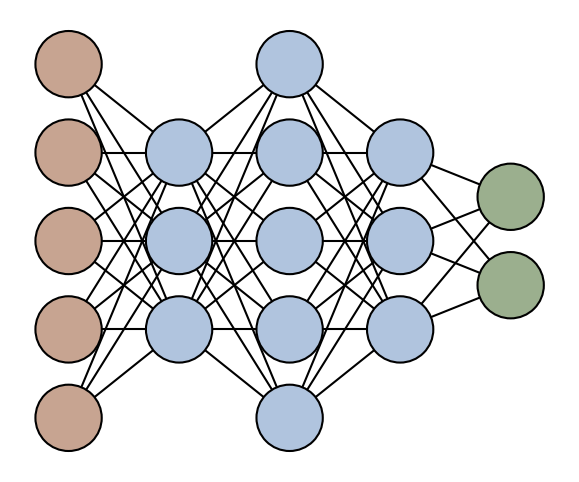

In [31]:
import matplotlib.pyplot as plt

def draw_network(input_size, hidden_size, output_size,
                 input_color='#BCB88A', hidden_color='#E6E6FA', output_color='#B0C4DE', radius=0.4, linewidth=1.5):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Positioning
    layer_sizes = [input_size, *hidden_size, output_size]
    v_spacing = 2.5 * radius + 0.1
    h_spacing = 2.0

    # Store coordinates
    node_coords = []

    for l_idx, layer in enumerate(layer_sizes):
        x = l_idx * h_spacing
        y_offset = - (layer - 1) * v_spacing / 2
        coords = []
        for n in range(layer):
            y = y_offset + n * v_spacing
            coords.append((x, y))
            color = [input_color, *(len(hidden_size) * [hidden_color]), output_color][l_idx]
            circle = plt.Circle((x, y), radius, color=color, ec='k', zorder=3, lw=linewidth)
            ax.add_patch(circle)
        node_coords.append(coords)

    # Draw connections
    for i, (layer1, layer2) in enumerate(zip(node_coords[:-1], node_coords[1:])):
        for (x1, y1) in layer1:
            for (x2, y2) in layer2:
                ax.plot([x1, x2], [y1, y2], 'k-', lw=linewidth, zorder=1)

    ax.set_aspect('equal')
    ax.axis('off')
    # plt.show()
    return fig, ax

fig, ax = draw_network(input_size=5, hidden_size=[3, 5, 3], output_size=2, radius=0.6, input_color='#C7A491', hidden_color='#B0C4DE', output_color='#9baf8e')
plt.show()
